In [ ]:
!pip install -q pyomo

In [ ]:
# https://jckantor.github.io/ND-Pyomo-Cookbook/notebooks/01.02-Running-Pyomo-on-Google-Colab.html#installing-pyomo-and-solvers
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

In [ ]:
import pyomo.environ as pyo
import numpy as np

def solve_baseline(params):
    a = params["a"]
    b = params["b"]
    pi = params["pi"]
    Dbar = np.array(params["Dbar"], dtype=float)
    Ds = params["Ds"]
    n = len(Dbar)
    k = params["k"]

    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, n-1)

    # variables (0 ≤ D_i ≤ Dbar_i)
    m.D = pyo.Var(m.I, bounds=lambda m,i: (0, float(Dbar[i])))

    # price
    def price(m, i):
        return a * m.D[i] + (b - a * Dbar[i])

    # objective: profit
    def obj_rule(m):
        return pi * sum(k[i] * m.D[i] for i in m.I) \
                - sum(k[i] * price(m,i) * m.D[i] for i in m.I)
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # capacity
    m.cap = pyo.Constraint(expr=sum(k[i] * m.D[i] for i in m.I) <= Ds)

    # solve
    solver = pyo.SolverFactory("ipopt")
    solver.solve(m, tee=False)

    # extract solution
    D = np.array([pyo.value(m.D[i]) for i in m.I])
    p = a*D + (b - a*Dbar)
    U = 0.5*a*D**2
    profit = pyo.value(m.obj)

    return dict(D=D, p=p, U=U, profit=profit)

In [ ]:
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
import numpy as np
from itertools import product


##############################################
# Solve the model for one alpha and one index
##############################################

def demand_from_price(idx, p, a, b, Dbar):
    if idx == 0:
        return 0
    elif idx == 2:
        return Dbar
    else:
        return (p-b)/a + Dbar

def solve_one_alpha(params, alpha, delta_x, index, Dbar_arr, solver):
    """
    Solve the optimization problem for a single (alpha, index) pair.

    If the model is infeasible or the solver fails, this function returns:
        D = None, p = None, U = None, profit = -1
    """

    # Unpack parameters
    a = params["a"]
    b = params["b"]
    pi = params["pi"]
    Ds = params["Ds"]
    n = len(Dbar_arr)
    k = params["k"]

    # Safety check: index must have one type per customer
    if len(index) != n:
        raise ValueError(f"len(index) = {len(index)} but n = {n}. "
                         "index must specify a type for each customer.")

    # Create a Pyomo model
    m = pyo.ConcreteModel()

    # Index set for customers
    m.I = pyo.RangeSet(0, n - 1)

    # Decision variables
    # p[i]: price, here also bounded in [0, Dbar[i]] (you can change this if needed)
    m.p = pyo.Var(m.I, bounds=lambda m, i: (0.0, None))

    # Constraint list (we will only use m.c.add(...))
    m.c = pyo.ConstraintList()

    # Type-specific constraints for the given indices
    # index is something like [0, 1] or [1, 2], etc.
    D_list = []
    for i in range(len(index)):
        idx = int(index[i])
        if idx == 0:
            m.c.add(m.p[i] <= b - a * Dbar_arr[i])
            D_list.append(0 * m.p[i])
        elif idx == 1:
            m.c.add(m.p[i] <= b)
            m.c.add(m.p[i] >= b - a * Dbar_arr[i])
            D_list.append((m.p[i]-b)/a + Dbar_arr[i])
        else:
            m.c.add(m.p[i] >= b)
            D_list.append(0 * m.p[i] + Dbar_arr[i])


    # Capacity constraint: total demand cannot exceed Ds
    m.c.add(sum([D_list[i] * k[i] for i in range(n)]) <= Ds)

    # Fairness bound: |p_i − p_j| ≤ (1 − alpha) * delta_x
    bound = (1.0 - float(alpha)) * float(delta_x)

    # Add pairwise fairness constraints using only m.c.add(...)
    for i in m.I:
        for j in m.I:
            if i < j:
                # p_i - p_j <= bound
                m.c.add(m.p[i] - m.p[j] <= bound)
                # -(p_i - p_j) <= bound  <=>  p_j - p_i <= bound
                m.c.add(-(m.p[i] - m.p[j]) <= bound)

     # Objective: maximize profit
    def obj_rule(m):
        return sum(
            k[i] * (pi - m.p[i]) * ((m.p[i] - b)/a + Dbar_arr[i]) if int(index[i]) == 1
              else k[i] * (pi - m.p[i]) * Dbar_arr[i] if int(index[i]) == 2
              else 0.0                                     # idx == 0
              for i in m.I)


    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # ---- Solve the model ----
    try:
        results = solver.solve(m, tee=False)#, load_solutions=False)
    except ValueError:
        # Solver failed hard (e.g., "Cannot load a SolverResults object ...")
        return dict(D=None, p=None, U=None, profit=-1)

    status = results.solver.status
    term = results.solver.termination_condition

    # If not solved to optimal/feasible, treat as infeasible
    if (status != SolverStatus.ok) or (
        term not in [
            TerminationCondition.optimal,
            TerminationCondition.locallyOptimal,
            TerminationCondition.feasible,
        ]
    ):
        return dict(D=None, p=None, U=None, profit=-1)

    # Extract solutions into numpy arrays
    p = np.array([pyo.value(m.p[i]) for i in m.I], dtype=float)
    D = np.array([demand_from_price(index[i], p[i], a, b, Dbar_arr[i]) for i in range(len(p))])
    # Compute utilities:
    # U_i = D_i * p_i − 1/2 * a * D_i^2 − (b − a * Dbar_i) * D_i
    U = D * p - 0.5 * a * D**2 - (b - a * Dbar_arr) * D

    # Get objective (profit) value
    profit = pyo.value(m.obj)

    return dict(D=D, p=p, U=U, profit=profit)


##############################################
# Simulation over many alphas and index sets
##############################################
def simulation(params, alphas, delta_x, index_candidates):
    """
    For each alpha, solve the model for all index candidates,
    and keep only the solution that yields the maximum profit.

    If all candidates are infeasible for a given alpha,
    that alpha will have:
        index = None, D = None, p = None, U = None, profit = -1
    """

    # Precompute Dbar as a numpy array (to avoid repeated conversion)
    Dbar_arr = np.array(params["Dbar"], dtype=float)

    # Create the solver only once (faster than recreating every time)
    solver = pyo.SolverFactory("ipopt")

    # Dictionary to store results
    res = {"alpha": [], "index": [], "D": [], "p": [], "U": [], "profit": []}

    # Loop over alpha values
    for alpha in alphas:
        best_sol = None
        best_index = None

        # Try all index combinations for this alpha
        for idx in index_candidates:
            sol = solve_one_alpha(params, alpha, delta_x, idx, Dbar_arr, solver)

            # skip infeasible ones (profit == -1)
            if sol["profit"] < 0:
                continue

            if (best_sol is None) or (sol["profit"] > best_sol["profit"]):
                best_sol = sol
                best_index = idx

        # If no feasible solution was found for this alpha
        if best_sol is None:
            res["alpha"].append(alpha)
            res["index"].append(None)
            res["D"].append(None)
            res["p"].append(None)
            res["U"].append(None)
            res["profit"].append(-1)
        else:
            res["alpha"].append(alpha)
            res["index"].append(best_index)
            res["D"].append(best_sol["D"])
            res["p"].append(best_sol["p"])
            res["U"].append(best_sol["U"])
            res["profit"].append(best_sol["profit"])

    return res


## Results

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_plot(params, res, ncol=3, regime_bounds=None):
    if regime_bounds is None:
        regime_bounds = []

    alpha_list = np.array(res["alpha"])
    n = len(res["D"][0])   # number of customers
    k = np.array(params['k'])

    lw = 2
    fig = plt.figure(figsize=(28, 5))

    # ---------------------------------------------------------
    # Grid: 1 row × 4 columns
    # First column is split into 4 rows
    # ---------------------------------------------------------
    gs = fig.add_gridspec(1, 4, wspace=0.25)

    gs0 = gs[0, 0].subgridspec(4, 1, hspace=0.12)
    ax0_pi  = fig.add_subplot(gs0[0])
    ax0_sw  = fig.add_subplot(gs0[3], sharex=ax0_pi)
    ax0_u   = fig.add_subplot(gs0[1], sharex=ax0_pi)
    ax0_nsw = fig.add_subplot(gs0[2], sharex=ax0_pi)

    ax_p = fig.add_subplot(gs[0, 1])
    ax_d = fig.add_subplot(gs[0, 2])
    ax_u_i = fig.add_subplot(gs[0, 3])

    # ---------------------------------------------------------
    # 1. Profit, utilities, welfare
    # ---------------------------------------------------------
    profit_list = np.array(res["profit"])
    U_total_list = np.array([
        sum(k[i] * U[i] for i in range(len(k)))
        for U in res["U"]
    ])

    NSW_list, SW_list = [], []
    for t in range(len(res["U"])):
        U_vec = np.array(res["U"][t])

        if np.all(U_vec > 0):
            NSW_list.append(np.sum(k * np.log(U_vec)))
        else:
            NSW_list.append(-np.inf)

        SW_list.append(U_total_list[t] + profit_list[t])

    NSW_list = np.array(NSW_list)
    SW_list  = np.array(SW_list)

    # ---- Row 1: Profit
    l_pi, = ax0_pi.plot(alpha_list, profit_list, 'r', lw=lw, label=r'$\Pi$')
    ax0_pi.set_xlim(0, 1)
    ax0_pi.tick_params(labelbottom=False)

    # ---- Row 4: NSW
    l_nsw, = ax0_nsw.plot(alpha_list, NSW_list, color='purple', lw=lw, label=r'$W_{CNW}$')
    ax0_nsw.set_xlim(0, 1)
    ax0_nsw.tick_params(labelbottom=False)


    # ---- Row 3: Total utility
    l_Utot, = ax0_u.plot(alpha_list, U_total_list, 'g', lw=lw, label=r'$U$')
    ax0_u.set_xlim(0, 1)
    ax0_u.tick_params(labelbottom=False)

    # ---- Row 2: Social welfare
    l_sw, = ax0_sw.plot(alpha_list, SW_list, color='blue', lw=lw, label=r'$W_{SW}$')
    ax0_sw.set_xlim(0, 1)
    ax0_sw.set_xlabel(r'$\alpha$', fontsize=24)


    _fontsize = 20
    # Figure-level legend (for the split first column)
    fig.legend(
        handles=[l_pi, l_nsw, l_Utot, l_sw],
        labels=[r'$\Pi$', r'$W_{CNW}$', r'$U$', r'$W_{SW}$', ],
        loc='upper left',
        bbox_to_anchor=(0.135, 1.11),
        ncol=2,
        fontsize=_fontsize,
        frameon=True,
    )

    # ---------------------------------------------------------
    # 2. Prices p_i (single axis)
    # ---------------------------------------------------------
    p_mat = np.array(res["p"])
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(max(n, 3))]
    colors = [colors[1]] + [colors[0]] + colors[2:]

    for i in range(n):
        ax_p.plot(alpha_list, p_mat[:, i],
                  label=fr'$p_{i+1}$',
                  lw=lw, color=colors[i])

    ax_p.set_xlim(0, 1)
    ax_p.set_xlabel(r'$\alpha$', fontsize=24)
    ax_p.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # 3. Demands D_i with dashed Dbar_i (single axis)
    # ---------------------------------------------------------
    D_mat = np.array(res["D"])
    Dbar = np.array(params["Dbar"])

    for i in range(n):
        ax_d.plot(alpha_list, D_mat[:, i],
                  label=fr'$D_{i+1}$',
                  lw=lw, color=colors[i])
        ax_d.axhline(Dbar[i], ls='--', lw=1.5, color=colors[i])

    ax_d.set_xlim(0, 1)
    ax_d.set_xlabel(r'$\alpha$', fontsize=24)
    ax_d.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # 4. Utilities U_i (single axis)
    # ---------------------------------------------------------
    U_mat = np.array(res["U"])
    for i in range(n):
        ax_u_i.plot(alpha_list, U_mat[:, i],
                    label=fr'$U_{i+1}$',
                    lw=lw, color=colors[i])

    ax_u_i.set_xlim(0, 1)
    ax_u_i.set_xlabel(r'$\alpha$', fontsize=24)
    ax_u_i.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                  ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # Regime bounds
    # ---------------------------------------------------------
    if regime_bounds:
        for bound in regime_bounds:
            for ax in [ax0_pi, ax0_sw, ax0_u, ax0_nsw, ax_p, ax_d, ax_u_i]:
                ax.axvline(bound, color='gray', ls='--', lw=1.2)

    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def draw_plot_except_CNW(params, res, ncol=3, regime_bounds=None):
    if regime_bounds is None:
        regime_bounds = []

    alpha_list = np.array(res["alpha"])
    n = len(res["D"][0])   # number of customers
    k = np.array(params['k'])

    lw = 2
    fig = plt.figure(figsize=(28, 5))

    # ---------------------------------------------------------
    # Grid: 1 row × 4 columns
    # First column is split into 4 rows
    # ---------------------------------------------------------
    gs = fig.add_gridspec(1, 4, wspace=0.25)

    gs0 = gs[0, 0].subgridspec(3, 1, hspace=0.12)
    ax0_pi  = fig.add_subplot(gs0[0])
    ax0_sw  = fig.add_subplot(gs0[2], sharex=ax0_pi)
    ax0_u   = fig.add_subplot(gs0[1], sharex=ax0_pi)
    # ax0_nsw = fig.add_subplot(gs0[2], sharex=ax0_pi)

    ax_p = fig.add_subplot(gs[0, 1])
    ax_d = fig.add_subplot(gs[0, 2])
    ax_u_i = fig.add_subplot(gs[0, 3])

    # ---------------------------------------------------------
    # 1. Profit, utilities, welfare
    # ---------------------------------------------------------
    profit_list = np.array(res["profit"])
    U_total_list = np.array([
        sum(k[i] * U[i] for i in range(len(k)))
        for U in res["U"]
    ])

    NSW_list, SW_list = [], []
    for t in range(len(res["U"])):
        U_vec = np.array(res["U"][t])
        NSW_list.append(np.sum(np.log(U_vec)) if np.all(U_vec > 0) else -np.inf)
        SW_list.append(U_total_list[t] + profit_list[t])

    NSW_list = np.array(NSW_list)
    SW_list  = np.array(SW_list)

    # ---- Row 1: Profit
    l_pi, = ax0_pi.plot(alpha_list, profit_list, 'r', lw=lw, label=r'$\Pi$')
    ax0_pi.set_xlim(0, 1)
    ax0_pi.tick_params(labelbottom=False)

    # ---- Row 4: NSW
    # l_nsw, = ax0_nsw.plot(alpha_list, NSW_list, color='purple', lw=lw, label=r'$W_{CNW}$')
    # ax0_nsw.set_xlim(0, 1)
    # ax0_nsw.tick_params(labelbottom=False)


    # ---- Row 3: Total utility
    l_Utot, = ax0_u.plot(alpha_list, U_total_list, 'g', lw=lw, label=r'$U$')
    ax0_u.set_xlim(0, 1)
    ax0_u.tick_params(labelbottom=False)

    # ---- Row 2: Social welfare
    l_sw, = ax0_sw.plot(alpha_list, SW_list, color='blue', lw=lw, label=r'$W_{SW}$')
    ax0_sw.set_xlim(0, 1)
    ax0_sw.set_xlabel(r'$\alpha$', fontsize=24)


    _fontsize = 20
    l_CNW = Line2D([], [], linestyle='-', linewidth=2, color='purple')
    # Figure-level legend (for the split first column)
    fig.legend(
        handles=[l_pi, l_CNW, l_Utot, l_sw],
        labels=[r'$\Pi$', r'$W_{CNW}$', r'$U$', r'$W_{SW}$', ],
        loc='upper left',
        bbox_to_anchor=(0.135, 1.11),
        ncol=2,
        fontsize=_fontsize,
        frameon=True,
    )

    # ---------------------------------------------------------
    # 2. Prices p_i (single axis)
    # ---------------------------------------------------------
    p_mat = np.array(res["p"])
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(max(n, 3))]
    colors = [colors[1]] + [colors[0]] + colors[2:]

    for i in range(n):
        ax_p.plot(alpha_list, p_mat[:, i],
                  label=fr'$p_{i+1}$',
                  lw=lw, color=colors[i])

    ax_p.set_xlim(0, 1)
    ax_p.set_xlabel(r'$\alpha$', fontsize=24)
    ax_p.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # 3. Demands D_i with dashed Dbar_i (single axis)
    # ---------------------------------------------------------
    D_mat = np.array(res["D"])
    Dbar = np.array(params["Dbar"])

    for i in range(n):
        ax_d.plot(alpha_list, D_mat[:, i],
                  label=fr'$D_{i+1}$',
                  lw=lw, color=colors[i])
        ax_d.axhline(Dbar[i], ls='--', lw=1.5, color=colors[i])

    ax_d.set_xlim(0, 1)
    ax_d.set_xlabel(r'$\alpha$', fontsize=24)
    ax_d.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # 4. Utilities U_i (single axis)
    # ---------------------------------------------------------
    U_mat = np.array(res["U"])
    for i in range(n):
        ax_u_i.plot(alpha_list, U_mat[:, i],
                    label=fr'$U_{i+1}$',
                    lw=lw, color=colors[i])

    ax_u_i.set_xlim(0, 1)
    ax_u_i.set_xlabel(r'$\alpha$', fontsize=24)
    ax_u_i.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01),
                  ncol=ncol, fontsize=_fontsize, frameon=True)

    # ---------------------------------------------------------
    # Regime bounds
    # ---------------------------------------------------------
    if regime_bounds:
        for bound in regime_bounds:
            for ax in [ax0_pi, ax0_sw, ax0_u, ax_p, ax_d, ax_u_i]:
                ax.axvline(bound, color='gray', ls='--', lw=1.2)

    plt.show()


{'alpha': [0, 0.1, 0.2, 0.3, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 'index': [[1, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1]], 'D': [array([-4.85819742e-07,  8.50204870e-01,  2.00049257e+00]), array([0.        , 0.85045358, 1.99995397]), array([0.        , 0.85045329, 1.99995458]), array([0.        , 0.85045346, 1.99995421]), array([0.        , 0.85045344, 1.99995428]), array([0.        , 0.85045188, 1.99995762]), array([0.        , 0.85045215, 1.99995705]), array([0.        , 0.84279647, 2.01642833]), array([0.        , 0.82957518, 2.04487415]), array([0.        , 0.81634813, 2.07333235]), array([0.        , 0.75022178, 2.21560419]), array([0.        , 0.6840937 , 2.35787976]), array([0.        , 0.61796534, 2.50015592]), array([0.        , 0.55183696, 2.64243214]), array([0.        , 0.4857085 , 2.78470851])], 'p': [array([4.53159438, 4.49345476, 4.4

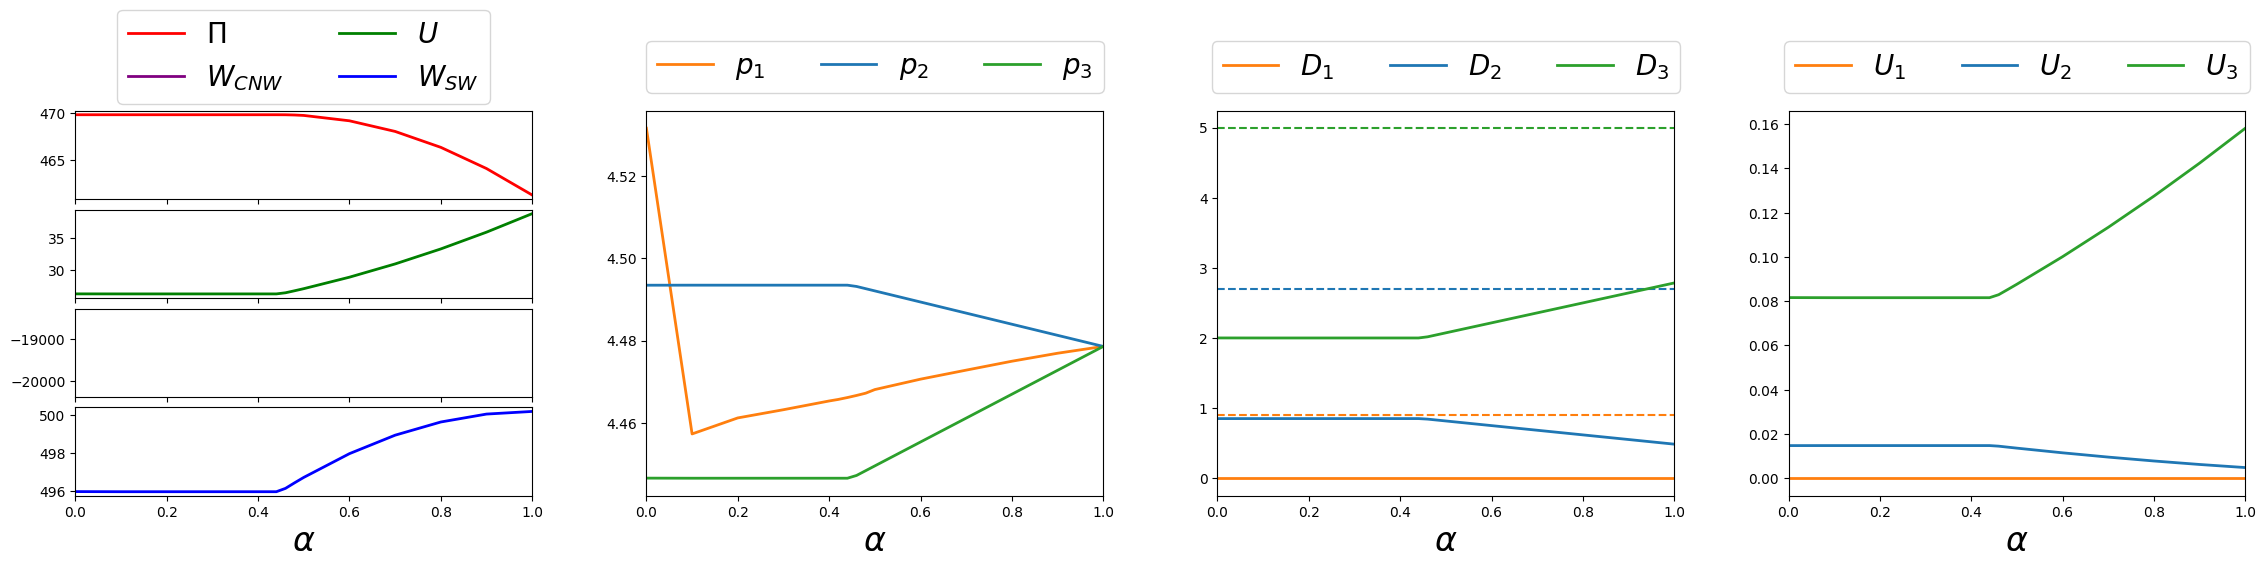

In [ ]:
import logging

logging.getLogger('pyomo.core').setLevel(logging.ERROR)
logging.getLogger('pyomo.opt').setLevel(logging.ERROR)

params = dict(
    a = 0.0408,
    b = 4.5686,
    pi = 5,
    Dbar = [0.907, 2.692, 4.991],
    k = [505, 497, 231],
    Ds = (505 * 0.907 + 497 * 2.692 + 231 * 4.991) * 0.3
)

sol0 = solve_baseline(params)  # ignore fairness
D0 = sol0["D"]
Dbar = np.array(params["Dbar"], dtype=float)

# demand fairness baseline Δ
delta_p = max(
    abs(params["a"] * D0[i] + (params["b"]-params["a"]*Dbar[i]) \
                - params["a"] * D0[j] - (params["b"]-params["a"]*Dbar[j]))
    for i in range(len(Dbar)) for j in range(i+1, len(Dbar))
)

alphas = [0,0.1,0.2,0.3,0.4,0.42,0.44,0.46,0.48,0.5,0.6,0.7,0.8,0.9,1]

# All index combinations [i, j] with i, j in {0, 1, 2}
index_candidates = [list(idx) for idx in product(range(3), repeat=3)]
# index_candidates = [[1,1]]

result = simulation(params, alphas, delta_p, index_candidates)
print(result)

draw_plot(params, result)

{'alpha': [0, 0.1, 0.2, 0.3, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 'index': [[0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1]], 'D': [array([0.        , 0.85019716, 2.00050566]), array([0.        , 0.8139776 , 2.07843257]), array([0.        , 0.77750463, 2.15690474]), array([0.        , 0.74102984, 2.23538079]), array([0.        , 0.7045555 , 2.31385589]), array([0.        , 0.69726061, 2.32955096]), array([0.        , 0.68996572, 2.34524603]), array([0.        , 0.68267083, 2.36094109]), array([0.        , 0.67537593, 2.37663617]), array([0.        , 0.66808104, 2.39233124]), array([0.        , 0.63160656, 2.47080664]), array([0.        , 0.59513206, 2.54928207]), array([0.        , 0.55865757, 2.6277575 ]), array([0.        , 0.52218308, 2.70623291]), array([0.        , 0.4857085 , 2.78470851])], 'p': [array([4.46636168, 4.49345444, 4.44658783]), arra

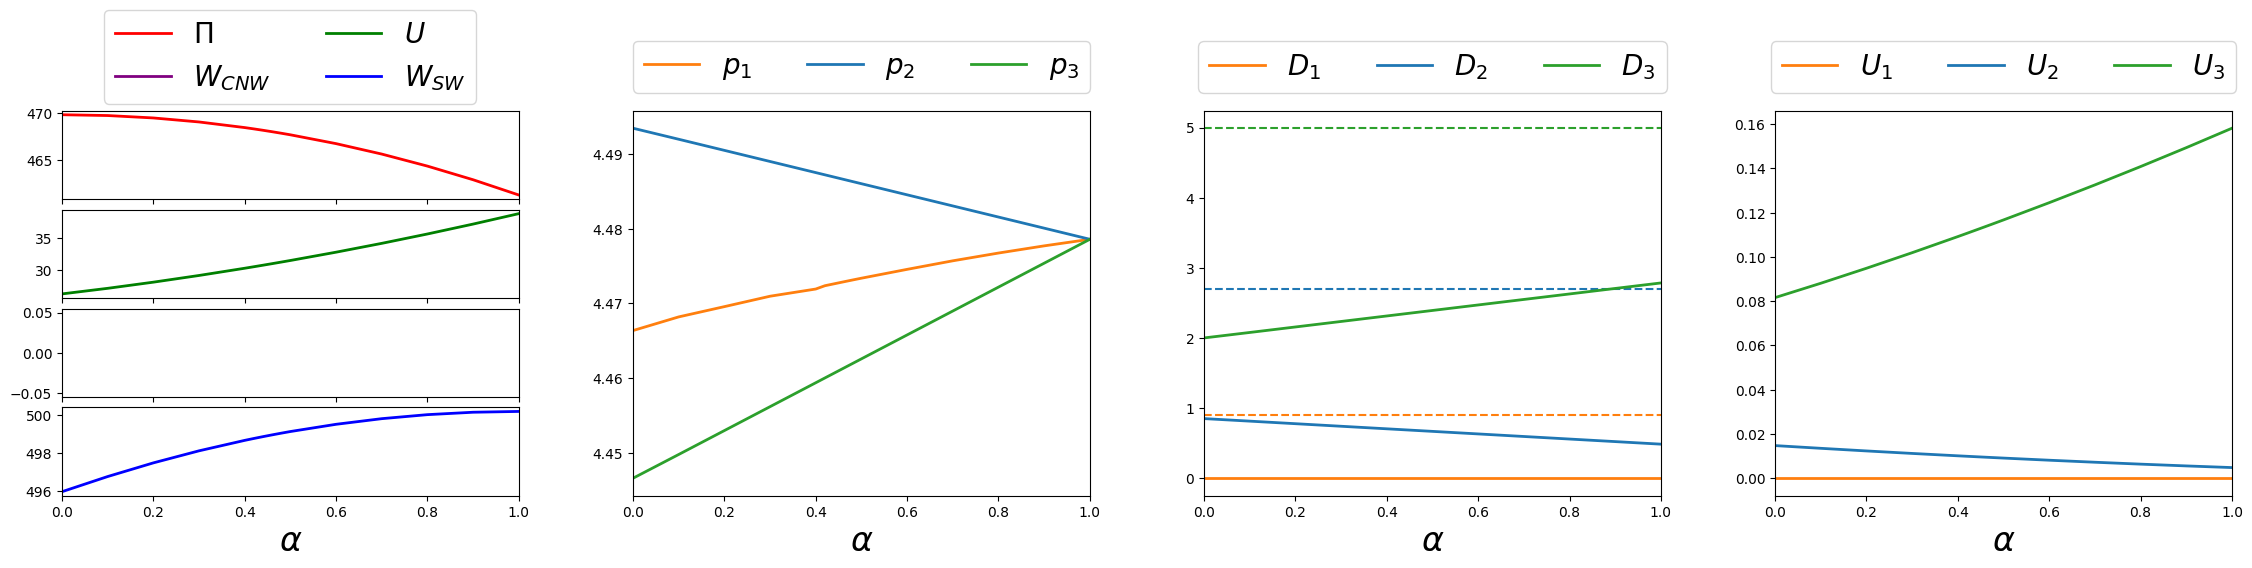

In [ ]:
import logging

logging.getLogger('pyomo.core').setLevel(logging.ERROR)
logging.getLogger('pyomo.opt').setLevel(logging.ERROR)

params = dict(
    a = 0.0408,
    b = 4.5686,
    pi = 5,
    Dbar = [0.907, 2.692, 4.991],
    k = [505, 497, 231],
    Ds = (505 * 0.907 + 497 * 2.692 + 231 * 4.991) * 0.3
)

sol0 = solve_baseline(params)  # ignore fairness
D0 = sol0["D"]
Dbar = np.array(params["Dbar"], dtype=float)

# demand fairness baseline Δ
delta_p = abs(params["a"] * D0[1] + (params["b"]-params["a"]*Dbar[1]) \
                - params["a"] * D0[2] - (params["b"]-params["a"]*Dbar[2]))

alphas = [0,0.1,0.2,0.3,0.4,0.42,0.44,0.46,0.48,0.5,0.6,0.7,0.8,0.9,1]

# All index combinations [i, j] with i, j in {0, 1, 2}
index_candidates = [list(idx) for idx in product(range(3), repeat=3)]
# index_candidates = [[1,1]]

result = simulation(params, alphas, delta_p, index_candidates)
print(result)

draw_plot(params, result)

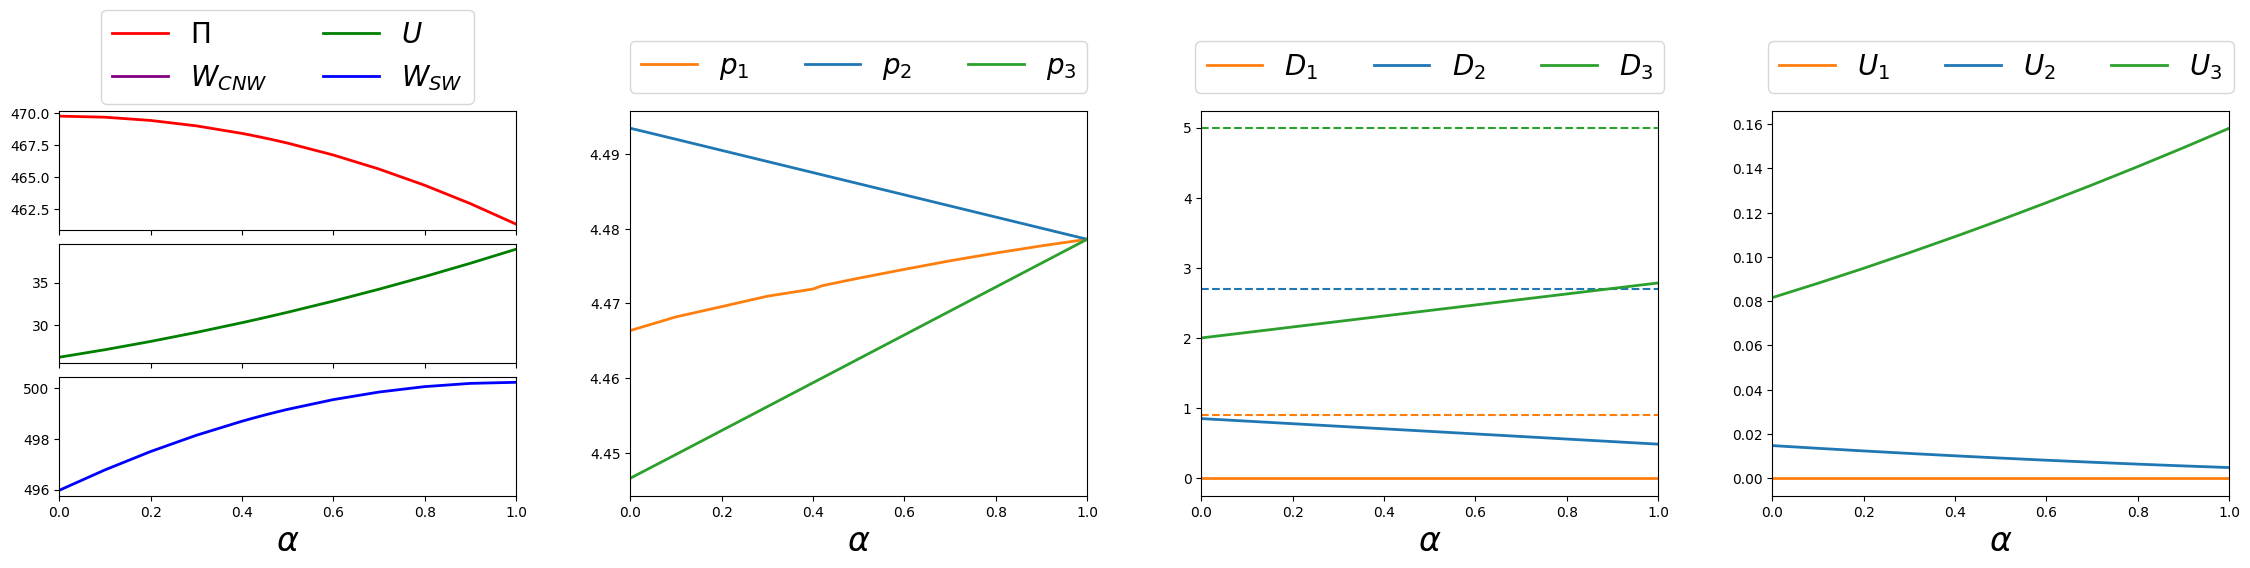

In [ ]:
draw_plot_except_CNW(params, result)

{'alpha': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.9, 1], 'index': [[1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1]], 'D': [array([0.90700106, 2.24638956, 3.39659837]), array([0.90700085, 2.17248607, 3.55560329]), array([0.90699992, 2.09835908, 3.71509069]), array([0.88048819, 2.06349141, 3.84806754]), array([0.83043189, 2.06349053, 3.95749986]), array([0.78037453, 2.06349124, 4.0669311 ]), array([0.7303181 , 2.06349052, 4.17636336]), array([0.68026062, 2.06349138, 4.28579453]), array([0.67024979, 2.06349063, 4.30768133]), array([0.66023682, 2.06349293, 4.32956618]), array([0.65021812, 2.06350376, 4.35144522]), array([0.63583236, 2.06998172, 4.36895719]), array([0.6170068 , 2.0830345 , 4.38202936]), array([0.52284172, 2.14835367, 4.44735293]), array([0.42867511, 2.21367511, 4.51267491])], 'p': [array([4.56860004, 4.55041909, 4.50354841]), arra

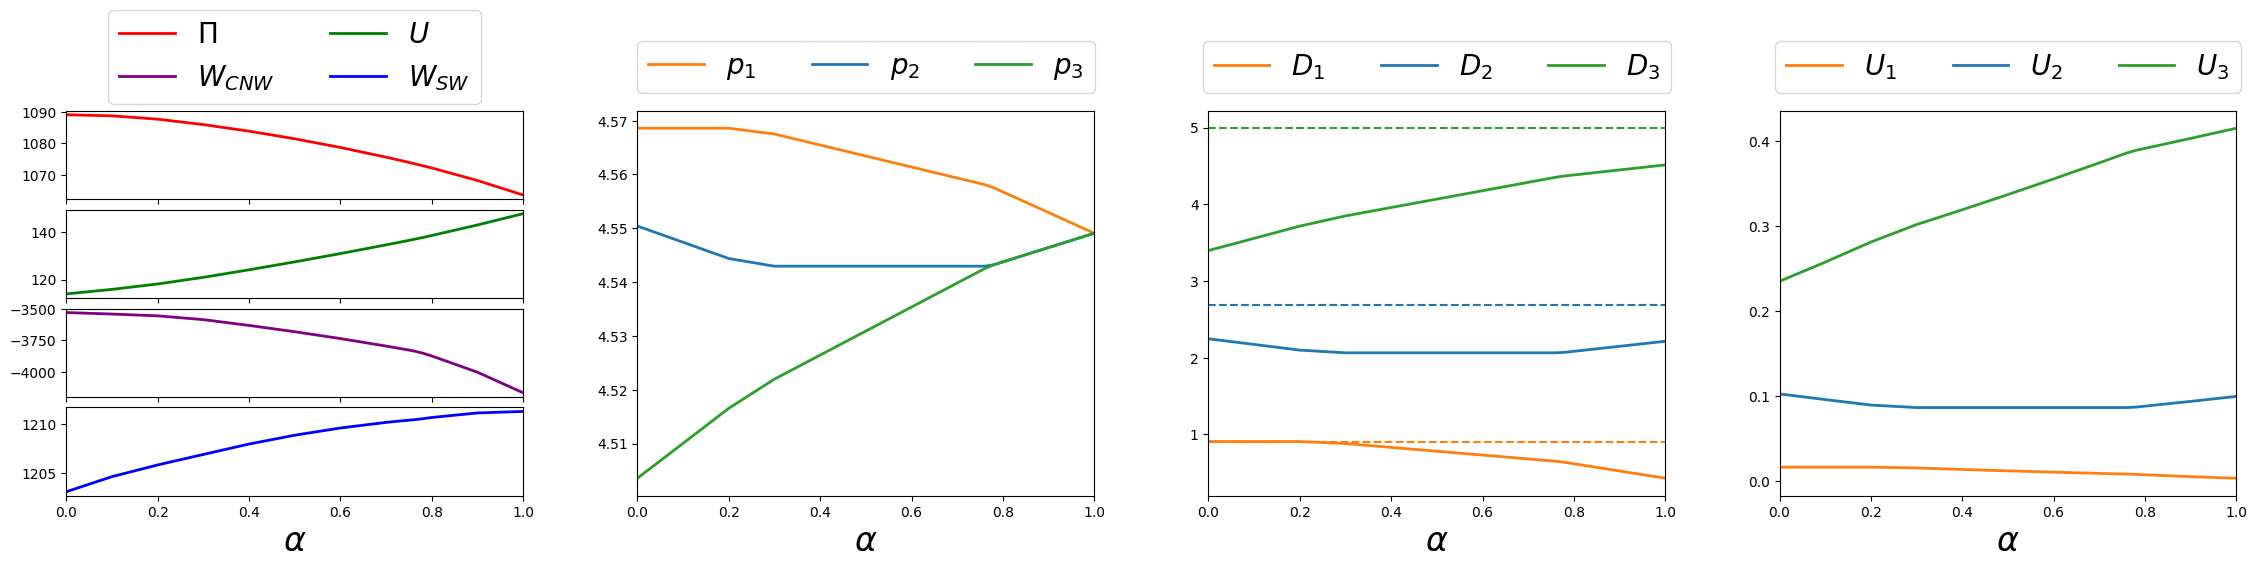

In [ ]:
params = dict(
    a = 0.0408,
    b = 4.5686,
    pi = 5,
    Dbar = [0.907, 2.692, 4.991],
    k = [505, 497, 231],
    Ds = (505 * 0.907 + 497 * 2.692 + 231 * 4.991) * 0.8
)

sol0 = solve_baseline(params)  # ignore fairness
D0 = sol0["D"]
Dbar = np.array(params["Dbar"], dtype=float)

# demand fairness baseline Δ
delta_p = max(
    abs(params["a"] * D0[i] + (params["b"]-params["a"]*Dbar[i]) \
                - params["a"] * D0[j] - (params["b"]-params["a"]*Dbar[j]))
    for i in range(len(Dbar)) for j in range(i+1, len(Dbar))
)

alphas = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.72,0.74,0.76,0.78,0.8,0.9,1]

# All index combinations [i, j] with i, j in {0, 1, 2}
index_candidates = [list(idx) for idx in product(range(3), repeat=3)]
# index_candidates = [[1,1]]

result = simulation(params, alphas, delta_p, index_candidates)
print(result)

draw_plot(params, result)